# NSE Real-Time Stock Price Predictor using LSTM

## Introduction
This notebook walks through building a complete stock price prediction pipeline for Indian NSE stocks using LSTM neural networks.

We will:
- Fetch real-time stock data using `yfinance`
- Preprocess and scale the data
- Build and train an LSTM model
- Predict the next day's closing price
- Visualize results

**Stock used for demonstration:** TCS (Tata Consultancy Services)


In [1]:
# Install required libraries (uncomment if running on Kaggle)
# !pip install yfinance scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Fetching Stock Data

We use `yfinance` to fetch 2 years of historical price data for TCS from NSE.
NSE stocks require `.NS` suffix in Yahoo Finance (e.g. `TCS.NS`).

In [12]:
# ============================================================
# KAGGLE NOTE: Yahoo Finance is blocked on Kaggle servers.
# We load a pre-downloaded CSV instead.
# For local use, uncomment the yfinance approach below — 
# it fetches live real-time data directly from NSE.
# ============================================================

# --- RECOMMENDED (Local Use) ---
# ticker = yf.Ticker(SYMBOL + ".NS")
# df = ticker.history(period=PERIOD)
# df = df[["Open", "High", "Low", "Close", "Volume"]]

# --- KAGGLE WORKAROUND ---
# Upload TCS.csv as a Kaggle dataset and attach it to this notebook
# df = pd.read_csv("/kaggle/input/tcs-nse-stock-data/TCS.csv", index_col="Date", parse_dates=True)
df = pd.read_csv("C:\\Users\\munta\\Desktop\\real_time_stock_predictor\\data\\raw_data\\TCS.csv", index_col="Date", parse_dates=True)
df = df[["Open", "High", "Low", "Close", "Volume"]]

print(f"Fetched {len(df)} trading days for {SYMBOL}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Fetched 497 trading days for TCS
Date range: 2024-05-15 to 2026-05-15


,Open,High,Low,Close,Volume
Date,,,,,
2024-05-15 00:00:00+05:30,3661.681650,3682.735453,3634.485142,3639.080322,1115021
2024-05-16 00:00:00+05:30,3675.637946,3693.018989,3630.673612,3684.942383,2599399
2024-05-17 00:00:00+05:30,3701.992424,3702.937051,3617.920639,3621.793701,2765804
2024-05-21 00:00:00+05:30,3618.487832,3631.854210,3599.075704,3608.663574,1908117
2024-05-22 00:00:00+05:30,3622.643939,3628.547857,3606.160247,3619.810059,1311168


## 2. Exploratory Data Analysis

Before building the model, let's understand the data visually.

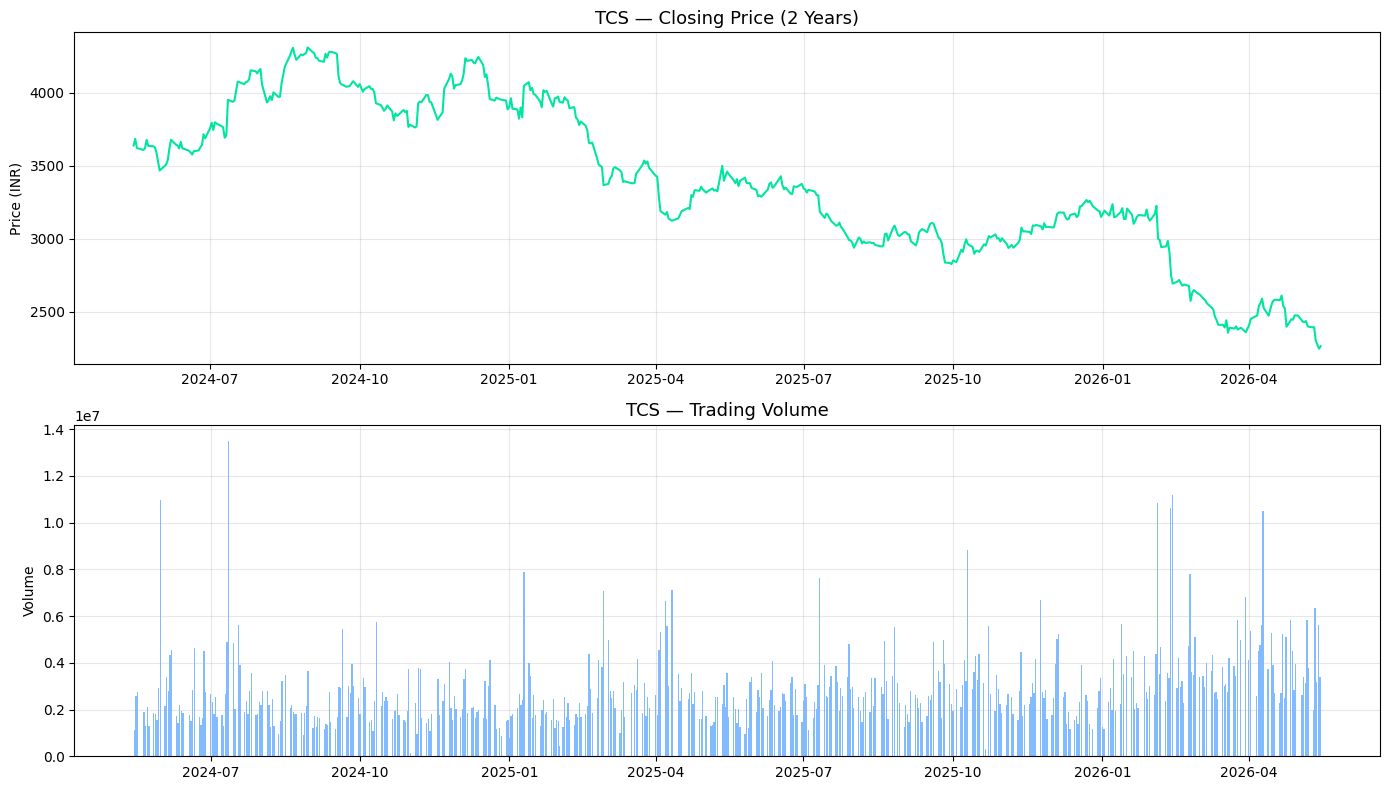


Basic Statistics:
count     497.00
mean     3392.68
std       524.94
min      2246.00
25%      3029.82
50%      3347.71
75%      3894.80
max      4311.59
Name: Close, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Closing price
axes[0].plot(df.index, df['Close'], color='#00e5a0', linewidth=1.5)
axes[0].set_title(f'{SYMBOL} — Closing Price (2 Years)', fontsize=13)
axes[0].set_ylabel('Price (INR)')
axes[0].grid(alpha=0.3)

# Volume
axes[1].bar(df.index, df['Volume'], color='#4d9fff', alpha=0.7)
axes[1].set_title(f'{SYMBOL} — Trading Volume', fontsize=13)
axes[1].set_ylabel('Volume')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
print(df['Close'].describe().round(2))

## 3. Preprocessing

We handle missing values and scale all features to [0, 1] using MinMaxScaler.
Scaling is essential for LSTM — large raw values like stock prices cause unstable gradients during training.

In [4]:
# Handle missing values
print(f"Missing values: {df.isnull().sum().sum()}")
df = df.dropna()

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print(f"Data shape: {scaled_data.shape}")
print(f"Value range after scaling: {scaled_data.min():.2f} to {scaled_data.max():.2f}")

Missing values: 0
Data shape: (497, 5)
Value range after scaling: 0.00 to 1.00


## 4. Creating Sequences

LSTM models learn from sequences of past data. We create input/output pairs where:
- **Input (X):** 60 consecutive days of all 5 features
- **Output (y):** The closing price of the next day

This is called a sliding window approach.

In [5]:
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 3])  # index 3 = Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)

# Chronological split — no shuffling for time series
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Input shape: {X_train.shape}")

Training samples: 349
Validation samples: 88
Input shape: (349, 60, 5)


## 5. Building the LSTM Model

Our architecture:
- **LSTM(60)** — first layer, returns full sequence
- **Dropout(0.2)** — prevents overfitting
- **LSTM(60)** — second layer, returns single vector
- **Dropout(0.2)** — prevents overfitting
- **Dense(1)** — output layer, predicts one value (Close price)

In [6]:
model = Sequential([
    LSTM(60, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(60, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 60)         │        15,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60)             │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,941 (175.55 KB)

 Trainable params: 44,941 (175.55 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training the Model

We use Early Stopping to prevent overfitting — training stops automatically when validation loss stops improving.

In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0789 - val_loss: 0.0084
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0206 - val_loss: 0.0184
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0119 - val_loss: 0.0056
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0110 - val_loss: 0.0077
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0090 - val_loss: 0.0030
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0070 - val_loss: 0.0027
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0070 - val_loss: 0.0034
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0073 - val_loss: 0.0026
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0066 - val_loss: 0.0026
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0061 - val_loss: 0.0040
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0058 - val_loss: 0.0030
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step

## 7. Training Results

Let's visualize how the model learned over time.

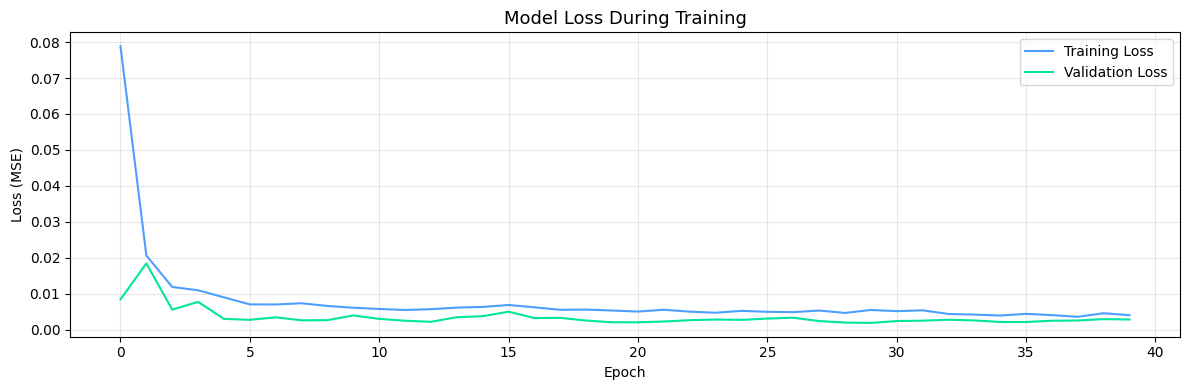

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss', color='#4d9fff', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#00e5a0', linewidth=1.5)
plt.title('Model Loss During Training', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Prediction

We use the last 60 days of data to predict tomorrow's closing price, then inverse-scale back to real rupee values.

In [9]:
# Get last 60 days
last_seq = scaled_data[-60:]
last_seq = last_seq.reshape(1, 60, 5)

# Predict
scaled_prediction = model.predict(last_seq)

# Inverse scale — dummy array trick
dummy = np.zeros((1, 5))
dummy[0, 3] = scaled_prediction[0, 0]
predicted_price = scaler.inverse_transform(dummy)[0, 3]

last_close = df['Close'].iloc[-1]
change = predicted_price - last_close
change_pct = (change / last_close) * 100

print(f"Last closing price:      ₹{last_close:.2f}")
print(f"Predicted closing price: ₹{predicted_price:.2f}")
print(f"Expected change:         ₹{change:.2f} ({change_pct:.2f}%)")
print(f"Direction:               {'▲ UP' if change > 0 else '▼ DOWN'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Last closing price:      ₹2264.00
Predicted closing price: ₹2354.52
Expected change:         ₹90.52 (4.00%)
Direction:               ▲ UP


## 9. Predicted vs Actual Prices

Let's visualize how well the model performs on the validation set compared to actual prices.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


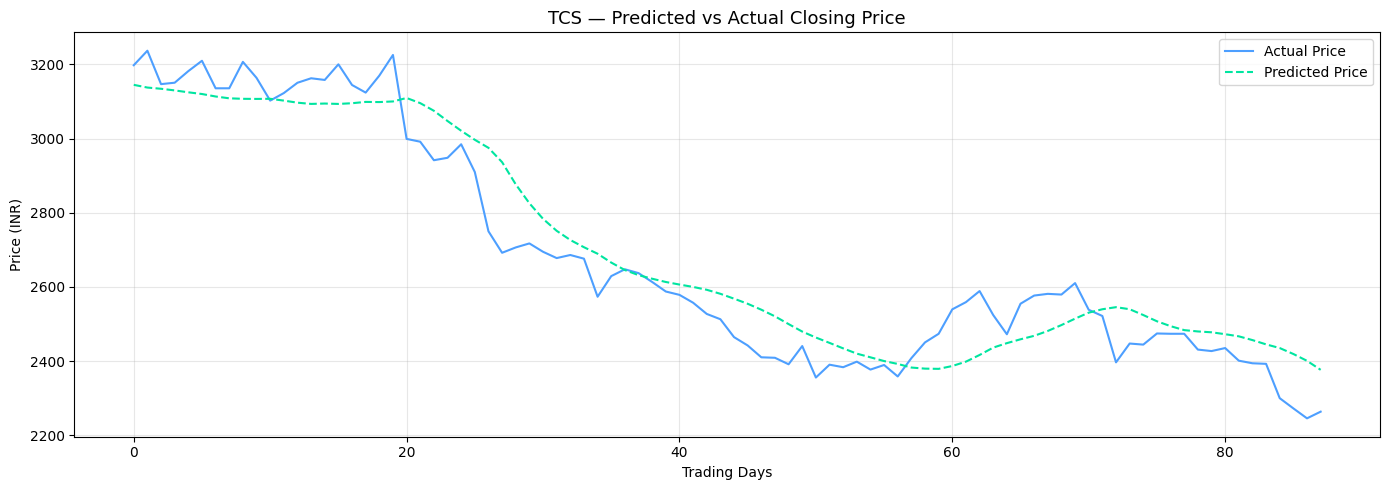

In [10]:
# Predict on validation set
val_predictions = model.predict(X_val)

# Inverse scale predictions
dummy_preds = np.zeros((len(val_predictions), 5))
dummy_preds[:, 3] = val_predictions[:, 0]
real_predictions = scaler.inverse_transform(dummy_preds)[:, 3]

# Inverse scale actual values
dummy_actual = np.zeros((len(y_val), 5))
dummy_actual[:, 3] = y_val
real_actual = scaler.inverse_transform(dummy_actual)[:, 3]

# Plot
plt.figure(figsize=(14, 5))
plt.plot(real_actual, label='Actual Price', color='#4d9fff', linewidth=1.5)
plt.plot(real_predictions, label='Predicted Price', color='#00e5a0', linewidth=1.5, linestyle='--')
plt.title(f'{SYMBOL} — Predicted vs Actual Closing Price', fontsize=13)
plt.xlabel('Trading Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Conclusion

### What we built
A complete end-to-end LSTM pipeline that:
- Fetches live NSE stock data via `yfinance`
- Preprocesses and scales data with `MinMaxScaler`
- Trains an LSTM model with early stopping
- Predicts next day's closing price
- Visualizes predicted vs actual prices

### Key Engineering Decisions
- **Chronological split** — no shuffling to prevent data leakage
- **MinMaxScaler** — scales to [0,1] for stable LSTM training
- **Dummy array trick** — inverse scaling a single column without affecting others
- **Sequence length = 60** — model looks at last 60 trading days (~3 months)

### Limitations
- Does not account for news, earnings, or market sentiment
- Past price patterns don't guarantee future performance
- Use for learning purposes only — not financial advice

### What's Next
- Replace LSTM with Transformer architecture
- Add sentiment analysis from financial news
- Deploy as a web application with FastAPI

---
*Built from scratch as part of a structured ML engineering learning roadmap.*
*Full project with FastAPI dashboard: [GitHub](https://github.com/muntazir-mehdi24/real-time-stock-predictor)*